# 04 — Head Movement Variability

Quantifies **how much and how unpredictably the subject moves their head** during the video. Related trust literature: variability in head movement has been linked to perceived engagement (moderate variability) vs nervousness or distraction (high / erratic variability).

Three complementary measures of variability:

1. **Rolling-window std** — short-term variability in each axis (pitch/yaw/roll). Shows *when* movement was happening.
2. **Total angular path length** — the cumulative distance traveled in 3D pose space. One scalar per video, answers *how much* the head moved overall.
3. **Sample entropy** — complexity / unpredictability of the pose signal. Low = smooth, repetitive motion; high = erratic, hard-to-predict motion.

**Input:** `data/<video>_merged.parquet` from `00_pipeline.ipynb`.  
**Outputs:** per-window variability series, summary stats table, 3-axis comparison plot, optional saved rolling-std parquet.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

- `WINDOW_SECONDS` — how long a window for the rolling std. 2s is a reasonable default (captures natural head-nod cadence without over-smoothing).
- `SAMPEN_M` — embedding dimension for sample entropy (2 is standard).
- `SAMPEN_R_FRAC` — tolerance for sample entropy as a fraction of the signal's std (0.2 is standard).

None of these require tuning for most videos; change only if results look suspicious.

In [2]:
VIDEO_STEM = "sample"

WINDOW_SECONDS = 2.0
SAMPEN_M = 2
SAMPEN_R_FRAC = 0.2

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
OUT_PATH = DATA_DIR / f"{VIDEO_STEM}_head_variability.parquet"

print("Input :", PARQUET_PATH)
print("Output:", OUT_PATH)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_head_variability.parquet


In [3]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS
WINDOW_FRAMES = max(2, int(round(WINDOW_SECONDS * FPS)))

pose = df[["frame", "timestamp", "pf_Pitch", "pf_Yaw", "pf_Roll"]].dropna().copy()
print(f"{len(pose)} sampled frames, effective fps = {FPS:.2f}")
print(f"Rolling-std window: {WINDOW_SECONDS}s = {WINDOW_FRAMES} frames")
pose.head(3)

165 sampled frames, effective fps = 6.00
Rolling-std window: 2.0s = 12 frames


,frame,timestamp,pf_Pitch,pf_Yaw,pf_Roll
0,0,0.000000,1.107137,4.032975,-0.665995
1,5,0.166667,-0.308955,0.677106,-1.319171
2,10,0.333333,-1.049357,0.496601,-0.951143


## 1. Rolling-window standard deviation

**What this section does:** at each frame, computes the standard deviation of pitch/yaw/roll within the surrounding `WINDOW_SECONDS` window. The result is one variability value per axis per frame — a time series of "how bouncy has the head been recently?"

**Why rolling std (and not a single global std):** a global std collapses everything to one number, losing *when* the movement happened. Rolling std keeps temporal structure — you can see bursts of motion vs calm stretches.

**How to read the output plot:**
- Flat-low std in an axis = head is steady along that axis in this window.
- Spike = transient head movement (a nod, a head-turn, a sudden lean).
- Sustained high std = ongoing restless motion on that axis.

**Axis reminder:**
- Pitch = nodding up/down
- Yaw = turning left/right
- Roll = tilting sideways

In [4]:
roll_std = pose[["pf_Pitch", "pf_Yaw", "pf_Roll"]].rolling(
    WINDOW_FRAMES, center=True, min_periods=max(2, WINDOW_FRAMES // 2)
).std()
roll_std.columns = ["pitch_std", "yaw_std", "roll_std"]
pose = pd.concat([pose.reset_index(drop=True), roll_std.reset_index(drop=True)], axis=1)

print(pose[["pitch_std", "yaw_std", "roll_std"]].describe().round(3))

       pitch_std  yaw_std  roll_std
count    165.000  165.000   165.000
mean       3.073    0.967     0.731
std        3.059    0.370     0.347
min        0.396    0.170     0.124
25%        1.023    0.714     0.489
50%        2.149    0.980     0.662
75%        3.579    1.183     0.897
max       14.273    1.823     1.668


## 2. Total angular path length

**What this section does:** treats each frame's `(pitch, yaw, roll)` as a point in 3D "pose space" and sums the Euclidean distance between consecutive frames. One scalar per video, in degrees.

**Why this is useful:** it's the most natural single-number answer to "how much did the head move in total?" Rolling std tells you *when* motion happened; path length tells you *how much accumulated motion* there was, regardless of when.

**Interpretation:**
- Normalize by duration (`path_length_per_second`) to compare videos of different lengths.
- Also report per-axis path lengths so you can see whether total motion was mostly nodding, turning, or tilting.

**Caveat:** path length captures *movement*, not *engagement*. A subject steadily tracking a moving stimulus with their head will score high here but be very focused. A subject with fidgety/anxious head motion also scores high. Sample entropy (Section 3) helps distinguish these.

**Note on frame skipping:** this signal is computed on sampled frames (every Nth frame of the source video). The path length is over the sampled trajectory, so it undercounts motion that happens between sampled frames. Use the same `SKIP_FRAMES` across videos you want to compare.

In [5]:
pose_arr = pose[["pf_Pitch", "pf_Yaw", "pf_Roll"]].to_numpy()
deltas = np.diff(pose_arr, axis=0)

path_per_axis = np.abs(deltas).sum(axis=0)
path_total = np.linalg.norm(deltas, axis=1).sum()
duration_s = len(pose) * frame_duration_s

path_stats = pd.Series({
    "pitch_path_deg": round(float(path_per_axis[0]), 2),
    "yaw_path_deg": round(float(path_per_axis[1]), 2),
    "roll_path_deg": round(float(path_per_axis[2]), 2),
    "total_path_deg": round(float(path_total), 2),
    "duration_s": round(duration_s, 2),
    "path_per_second": round(float(path_total) / duration_s, 2) if duration_s else float("nan"),
})
path_stats

pitch_path_deg     212.34
yaw_path_deg       127.29
roll_path_deg       73.45
total_path_deg     294.64
duration_s          27.50
path_per_second     10.71
dtype: float64

## 3. Sample entropy (per axis)

**What this section does:** measures the **complexity** (unpredictability) of each pose axis time series. Sample entropy `SampEn(m, r, N)` answers: *given the recent m points, how hard is it to predict the next point?*

**How it's computed:**
1. For embedding dimension `m`, find all pairs of length-m subsequences in the signal that are "similar" (within tolerance `r`).
2. Find all pairs of length-(m+1) subsequences that are similar.
3. `SampEn = −ln(count_m+1 / count_m)`.
4. Low values → high predictability (many length-m matches also extend to length-(m+1)). High values → low predictability.

**Parameters:** `m=2`, `r = 0.2 × std(signal)` are standard in the literature. Scaling `r` by the signal's own std makes sample entropy comparable across subjects with different overall motion ranges.

**What each value range roughly means (for head pose):**
- `~0.0–0.4` — very regular motion (steady head, periodic nod).
- `~0.5–1.0` — typical natural conversation.
- `~1.2+` — highly irregular motion (fidgety, restless).

These ranges are rough guides, not hard thresholds — calibrate against your own corpus.

**Why not just use std?** Std measures amount, entropy measures structure. Two subjects can have the same std but very different entropy: one doing slow rhythmic nods (low entropy), another doing erratic twitches (high entropy).

In [6]:
def sample_entropy(x: np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample entropy. x: 1D array. m: embedding dim. r: tolerance (defaults to 0.2*std)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    N = len(x)
    if N < m + 2:
        return float("nan")
    if r is None:
        r = 0.2 * np.std(x)
    if r == 0:
        return float("nan")

    def _count(m_):
        # Build N-m_+1 templates of length m_, count pairs with max-abs-diff <= r
        templates = np.array([x[i:i+m_] for i in range(N - m_ + 1)])
        count = 0
        for i in range(len(templates)):
            diffs = np.max(np.abs(templates[i+1:] - templates[i]), axis=1)
            count += int((diffs <= r).sum())
        return count

    B = _count(m)
    A = _count(m + 1)
    if B == 0 or A == 0:
        return float("inf")
    return -np.log(A / B)

entropies = {}
for axis_name, col in [("pitch", "pf_Pitch"), ("yaw", "pf_Yaw"), ("roll", "pf_Roll")]:
    x = pose[col].to_numpy()
    r = SAMPEN_R_FRAC * np.std(x)
    entropies[axis_name] = round(sample_entropy(x, m=SAMPEN_M, r=r), 3)

entropies

{'pitch': 0.629, 'yaw': 1.341, 'roll': 1.142}

## 4. Summary stats table

**What this table is for:** a single-glance view of movement across all three axes and all three metrics. Use it to:
- Compare axes within a subject (does this subject nod more than they turn?).
- Compare subjects or conditions (is condition A more restless than condition B?).
- Spot weirdness (sample entropy near 0 or very high suggests a detection problem).

**Columns:**
- `mean_angle` — average pose angle. Not a variability measure; shows whether the subject's resting head pose was off-center (e.g. chin-down posture would show negative mean pitch).
- `std_angle` — global std of the axis. The "overall how wobbly" number.
- `path_deg` — accumulated travel on that axis.
- `sample_entropy` — complexity on that axis.

In [7]:
summary = pd.DataFrame({
    "mean_angle": [pose["pf_Pitch"].mean(), pose["pf_Yaw"].mean(), pose["pf_Roll"].mean()],
    "std_angle":  [pose["pf_Pitch"].std(),  pose["pf_Yaw"].std(),  pose["pf_Roll"].std()],
    "path_deg":   [path_per_axis[0], path_per_axis[1], path_per_axis[2]],
    "sample_entropy": [entropies["pitch"], entropies["yaw"], entropies["roll"]],
}, index=["pitch", "yaw", "roll"]).round(3)
summary.loc["TOTAL"] = [float("nan"), float("nan"), round(float(path_total), 3), float("nan")]
summary

,mean_angle,std_angle,path_deg,sample_entropy
pitch,-2.738,6.178,212.337,0.629
yaw,2.048,1.250,127.293,1.341
roll,-1.287,1.230,73.450,1.142
TOTAL,NaN,NaN,294.640,NaN


## 5. Three-axis comparison plot

**Top panel:** raw pitch/yaw/roll over time — shows the actual head trajectory.

**Bottom panel:** rolling-std over time — shows *when* the motion happened. Tall spikes in a given axis = that's when the head was moving most on that axis.

**What to look for:**
- Mostly-flat raw line with spikes → subject was still and then made discrete movements.
- Continuous wiggle → subject was fidgety throughout.
- One axis dominates (e.g. yaw much larger than pitch/roll) → subject was doing specific movements (scanning left/right).

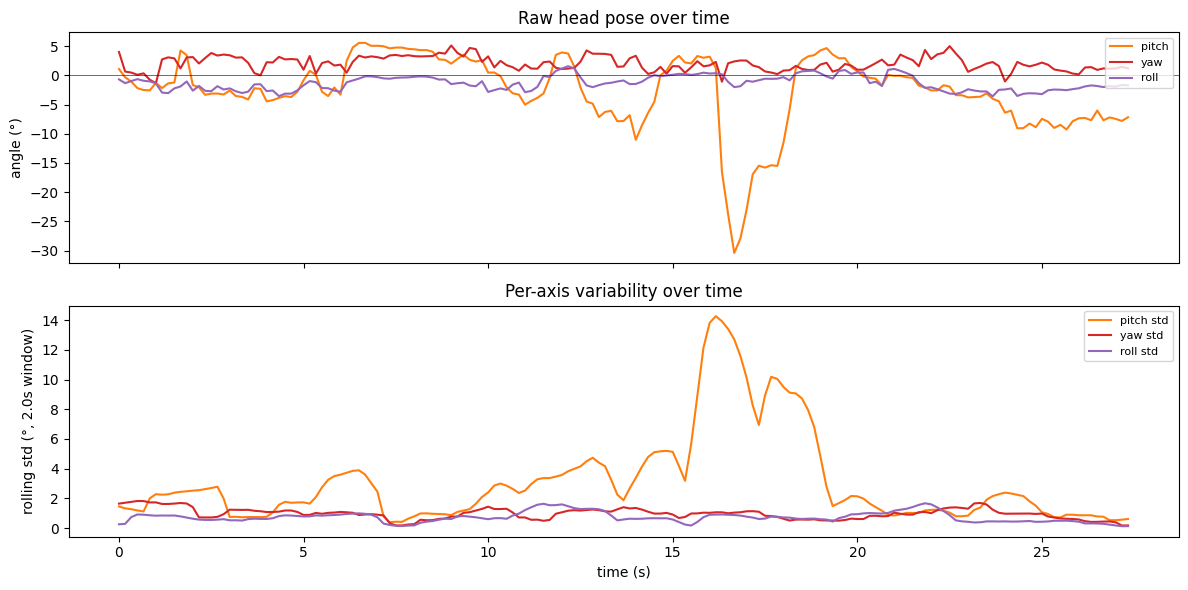

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = pose["timestamp"].to_numpy()

axes[0].plot(t, pose["pf_Pitch"], label="pitch", color="tab:orange")
axes[0].plot(t, pose["pf_Yaw"], label="yaw", color="tab:red")
axes[0].plot(t, pose["pf_Roll"], label="roll", color="tab:purple")
axes[0].axhline(0, color="k", lw=0.4)
axes[0].set_ylabel("angle (°)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Raw head pose over time")

axes[1].plot(t, pose["pitch_std"], label="pitch std", color="tab:orange")
axes[1].plot(t, pose["yaw_std"], label="yaw std", color="tab:red")
axes[1].plot(t, pose["roll_std"], label="roll std", color="tab:purple")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel(f"rolling std (°, {WINDOW_SECONDS}s window)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("Per-axis variability over time")

plt.tight_layout()
plt.show()

## 6. Save rolling-std time series for reuse

In [ ]:
out = pose[["frame", "timestamp", "pf_Pitch", "pf_Yaw", "pf_Roll",
            "pitch_std", "yaw_std", "roll_std"]].copy()
out.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}  ({len(out)} rows)")